# <b>Modelo de Previsão para Séries Temporais</b><br> <i>Custo com Água

## Componentes das Séries Temporais

 Uma série temporal pode ser decomposta em:
 - **Tendência:** direção de longo prazo
 - **Sazonalidade:** repetição periódica de padrões
 - **Ruído:** variação aleatória

### Importação das bibliotecas

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.tsa.stattools
import sys
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
#from statsmodels.tsa.stattools import adfuller, kpss, acf

### Importação de módulo com configurações para gráficos

In [17]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

from src.scripts.plot_config import set_seaborn
set_seaborn()

### Carregamento e pré-visualização dos dados

In [18]:
df = pd.read_csv(
    "../../data/processed/processed_water.csv",
    usecols=["VALOR_FATURA", "DATA_VENCIMENTO"],
    index_col="DATA_VENCIMENTO",
    parse_dates=["DATA_VENCIMENTO"]
)

df = df.resample('ME').sum(numeric_only=True)
df.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,2266691.11
2022-03-31,2243767.25
2022-04-30,2861797.77


### Visualização da Série Temporal

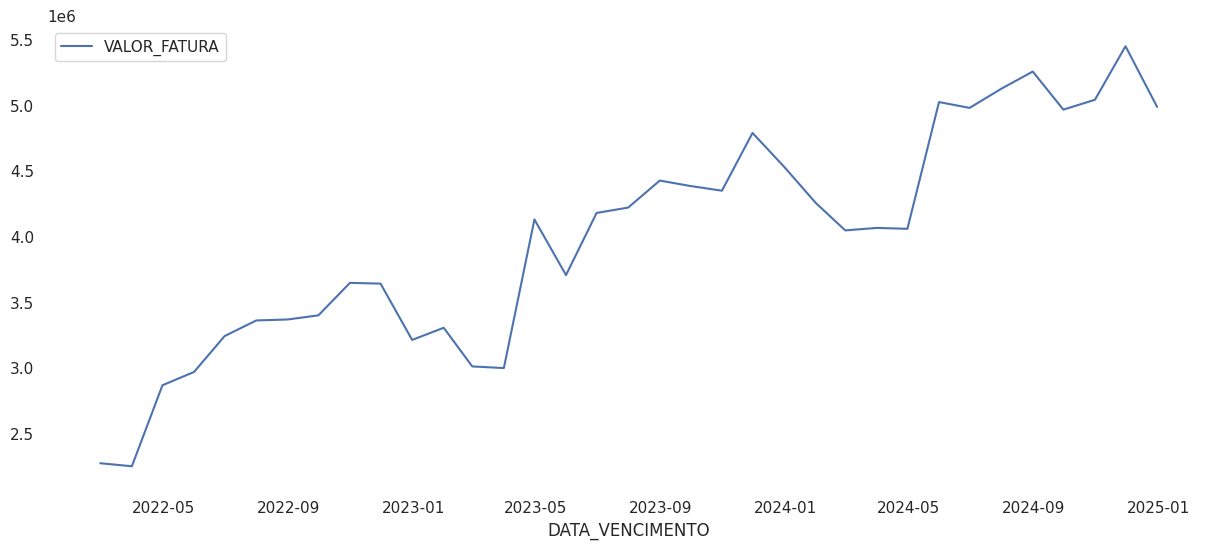

In [19]:
sns.lineplot(df);

### Correlograma
Gráfico de autocorrelação (ACF)<br>
Pontos fora do intervalo de confiança indicam autocorrelação

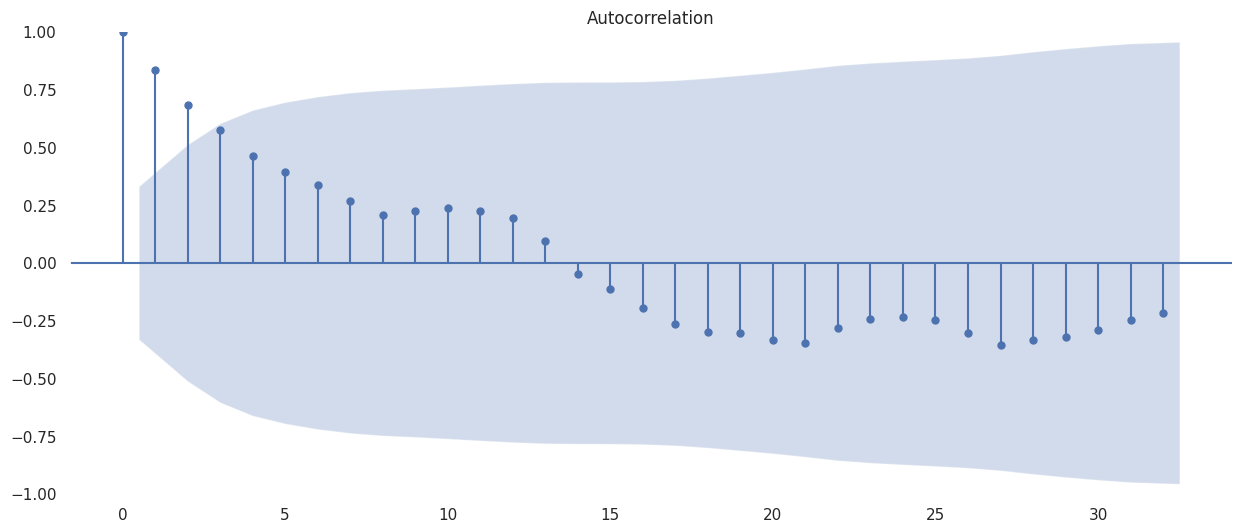

In [20]:
plot_acf(df, lags=32);

### Teste de Normalidade dos Dados com QQ Plot e Shapiro-Wilk

QQ Plot

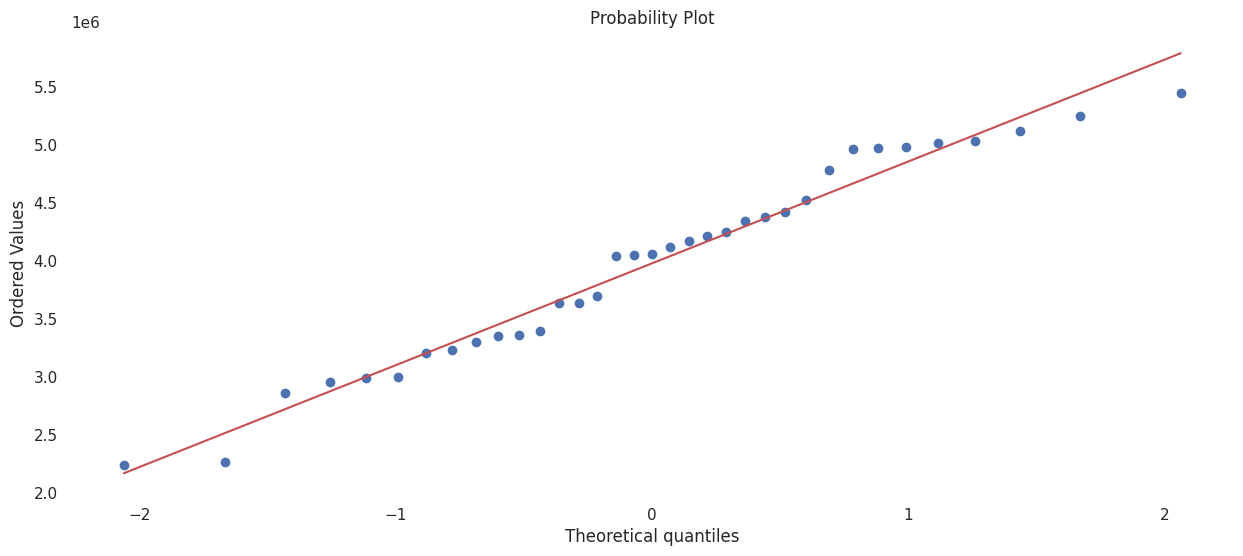

In [25]:
stats.probplot(df["VALOR_FATURA"], dist="norm", plot=plt)
plt.show()

Teste Shapiro-Wilk

CRITÉRIOS:<br>
NÍVEL DE SIGNIFICÂNCIA DE 0,05 ou 5% (MAIS UTILIZADO)

* H0: A série segue uma distribuição aproximadamente normal QUANDO p > 0,05.
* Ha: A série NÃO segue uma distribuição aproximadamente normal QUANDO p < 0,05.

In [26]:
e, p = stats.shapiro(df)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9643419620253055
p-valor: 0.30734068019894234


#### Transformação por log 

Diminui variância e melhora normalidade<br>
Aplica a função logarítmica em todos os dados da série

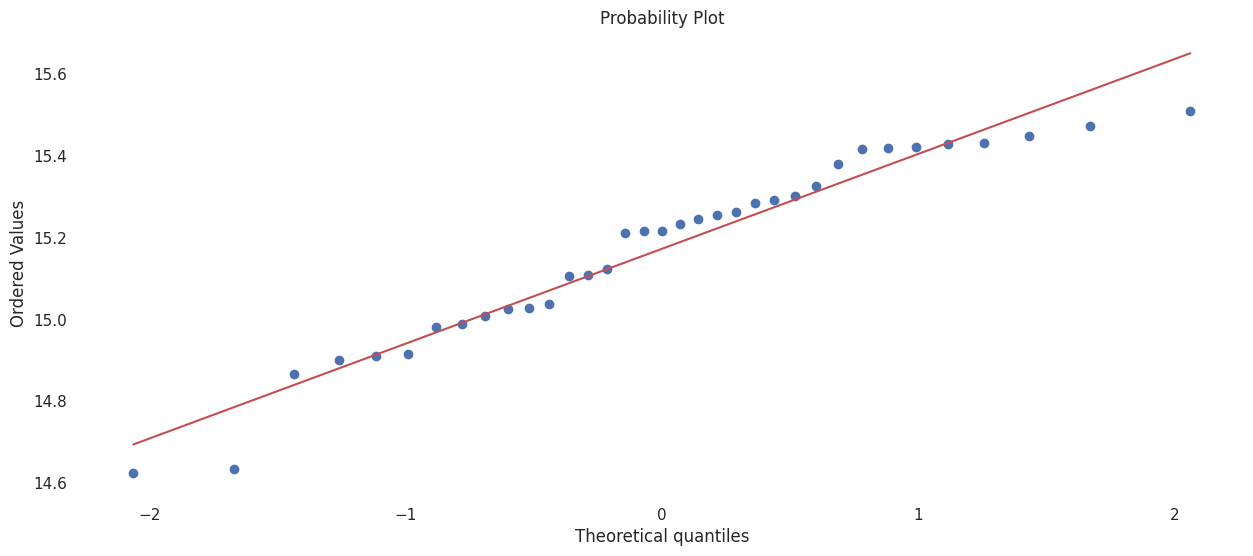

In [28]:
df_log = np.log(df)

stats.probplot(df_log["VALOR_FATURA"], dist="norm", plot=plt)
plt.show()

In [29]:
e, p = stats.shapiro(df_log)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9439626013617578
p-valor: 0.07394581409790711


#### Transformação por raiz cúbica

Transformação muito utilizada quando a série possui dados com valor zero ou negativos

In [30]:
df_square = np.sign(df)*abs(df)**(1/3)

e, p = stats.shapiro(df_square)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9539924274876816
p-valor: 0.15025324174200883


#### Histograma para análise da distribuição entre as séries normalizadas

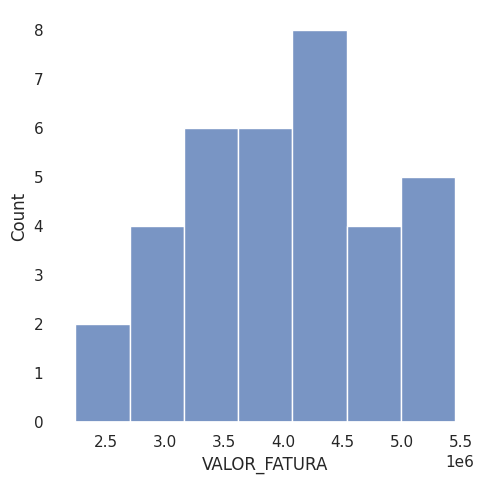

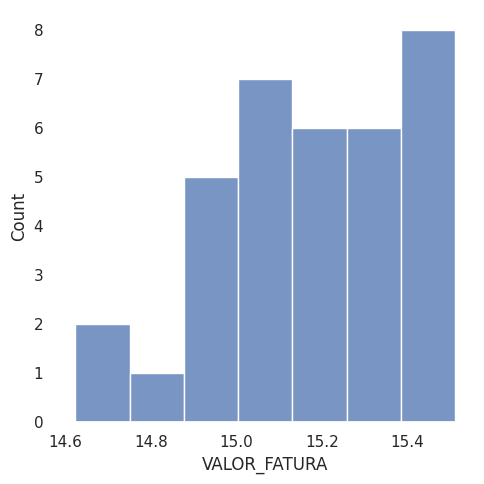

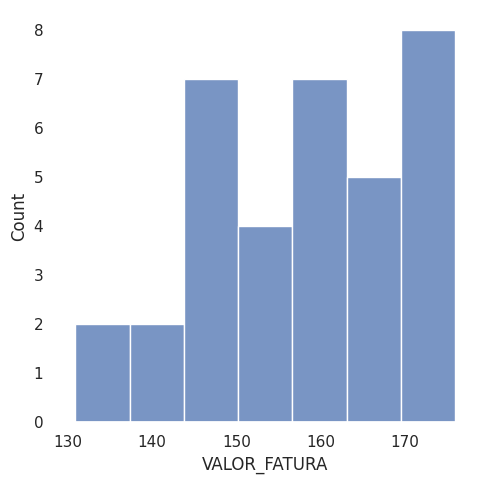

In [31]:
series = [df, df_log, df_square]
for i in series:
    sns.displot(i["VALOR_FATURA"]);

### Eliminação do ruído (suavização) com média movel para análise de tendência

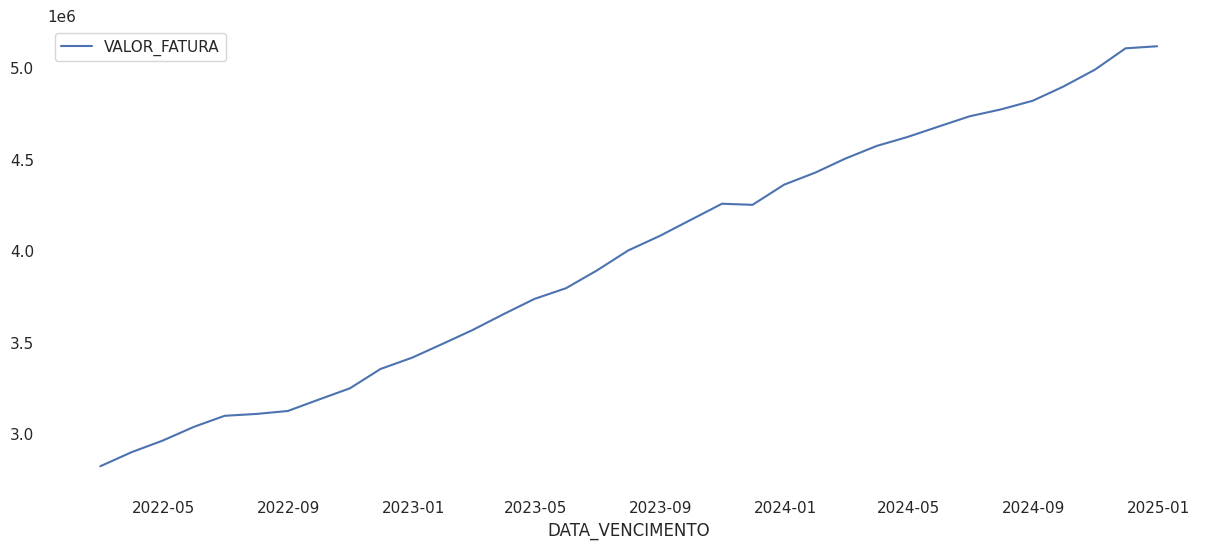

In [37]:
tendencia = df.rolling(window=12, center=True, min_periods=1).mean()
sns.lineplot(tendencia);

### Teste de Estacionaridade

***Teste de Dickey-Fuller Aumentado (ADF)*** O teste de Dickey-Fuller
Aumentado (ADF) é um teste de hipótese usado para verificar a
estacionaridade de uma série temporal.

-   **Hipótese Nula (H0)**: A série temporal tem uma raiz unitária (não
    estacionária).

-   **Hipótese Alternativa (H1)**: A série temporal é estacionária (sem
    raiz unitária).

-   **Rejeitar H0 (valor** $p$ \< 0.05): A série é estacionária.

-   **Não rejeitar H0 (valor** $p$ \> 0.05): A série não é estacionária
    (tem raiz unitária).

In [38]:
adf_result = statsmodels.tsa.stattools.adfuller(df, autolag='AIC')
print('ADF Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(adf_result[0]))
print('p-valor: {:.4f}'.format(adf_result[1]))
print('Valores Críticos:')
for chave, valor in adf_result[4].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.")
print('\n')

ADF Test: Ruído Branco
Estatística do teste: -1.8292
p-valor: 0.3661
Valores Críticos:
1%: -3.6392
5%: -2.9512
10%: -2.6144
Resultado:
Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.




#### Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

O teste KPSS é usado para verificar a estacionaridade de uma série
temporal, mas ao contrário do teste ADF, sua hipótese nula é que a série
é estacionária.

##### Hipóteses:

-   **Hipótese Nula (H0)**: A série temporal é estacionária.

-   **Hipótese Alternativa (H1)**: A série temporal não é estacionária.

-   **Rejeitar H0 (valor KPSS grande )**: A série não é estacionária.

-   **Não rejeitar H0 (valor KPSS pequeno)**: A série é estacionária.

In [39]:
kpss_result = statsmodels.tsa.stattools.kpss(df, regression='c')
print('KPSS Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(kpss_result[0]))
print('p-valor: {:.4f}'.format(kpss_result[1]))
print('Valores Críticos:')
for chave, valor in kpss_result[3].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if kpss_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados não são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados são estacionários.")
print('\n')

KPSS Test: Ruído Branco
Estatística do teste: 0.9108
p-valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Rejeitar a hipótese nula (H0): Os dados não são estacionários.




/tmp/ipykernel_85860/2765764661.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = statsmodels.tsa.stattools.kpss(df, regression='c')


### Remoção da tendência com diferenciação para tornar a série estacionária
<code>diff(1)</code> subtrai o valor anterior do atual, ou seja:
$$
y_t' = y_t - y_{t-1}
$$

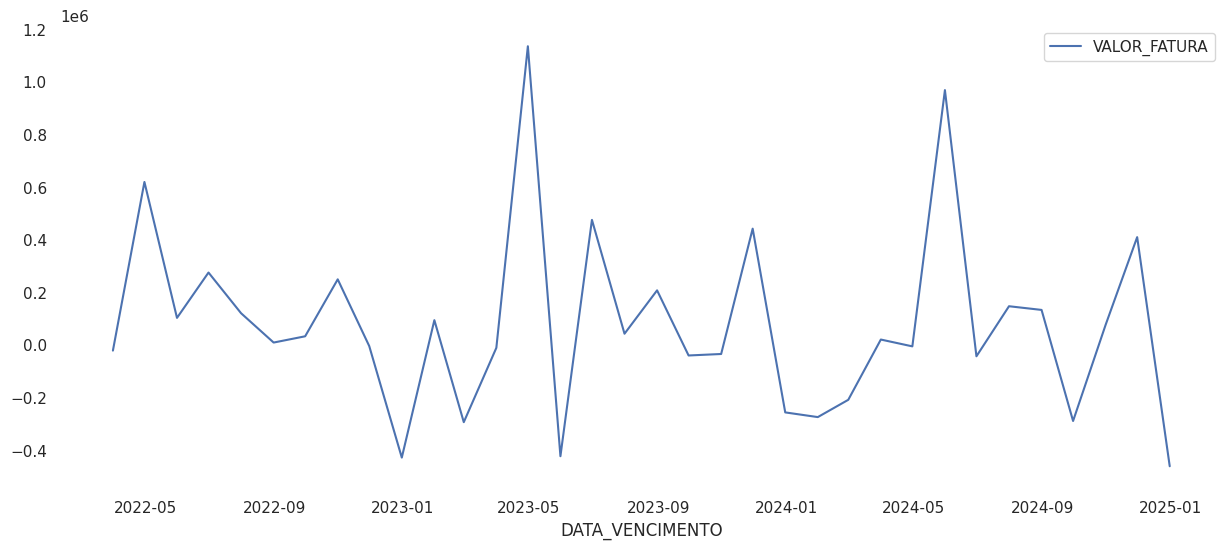

In [40]:
diferenca = df.diff(1)
sns.lineplot(diferenca);

In [41]:
diferenca_1 = df.diff(1).dropna()

kpss = statsmodels.tsa.stattools.kpss(diferenca_1)
print('Estatítica do teste: {:.4f}'.format(kpss[0]))
print('p_valor: {:.4f}'.format(kpss[1]))
print('Valores Críticos:')
for chave, valor in kpss[3].items():
   print('{}: {:.4f}'.format(chave, valor))

Estatítica do teste: 0.0886
p_valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


/tmp/ipykernel_85860/1793646151.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss = statsmodels.tsa.stattools.kpss(diferenca_1)


Como a estatística do teste é menor que o valor crítico, temos que a série é estacionária<br>
Caso não tivesse chegado a estacionaridade poderíamos realizar a Diferenciação de segunda ordem.

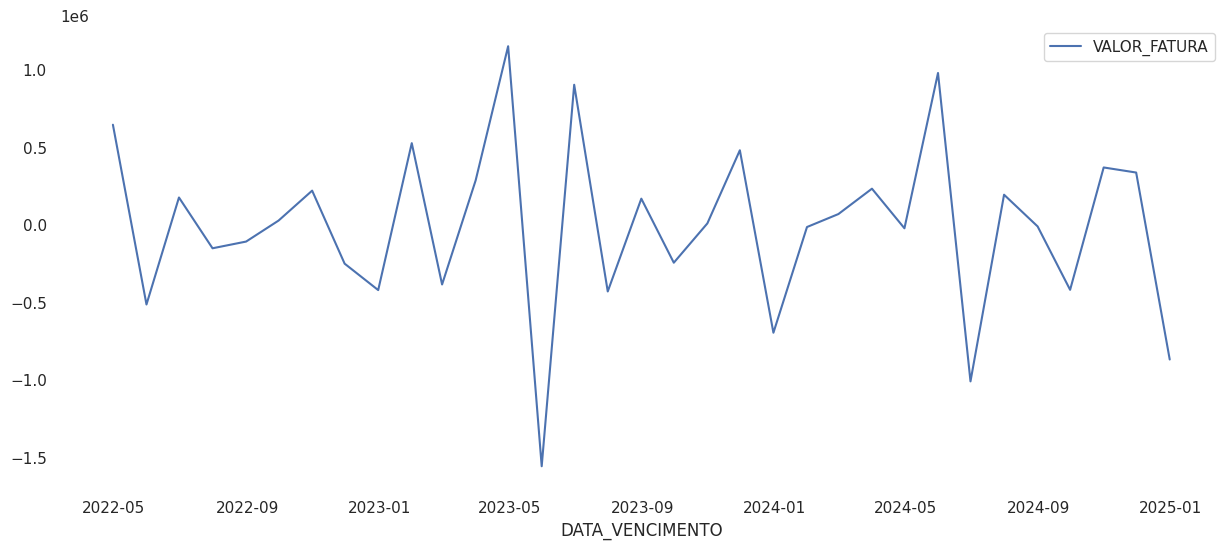

In [42]:
diferenca_2 = diferenca_1.diff(1).dropna()
sns.lineplot(diferenca_2);

In [43]:
kpss = statsmodels.tsa.stattools.kpss(diferenca_2)
print('Estatítica do teste: {:.4f}'.format(kpss[0]))
print('p_valor: {:.4f}'.format(kpss[1]))
print('Valores Críticos:')
for chave, valor in kpss[3].items():
   print('{}: {:.4f}'.format(chave, valor))

Estatítica do teste: 0.5000
p_valor: 0.0417
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


### Isolamento da sazonalidade para identificar padrões periódicos recorrentes na série

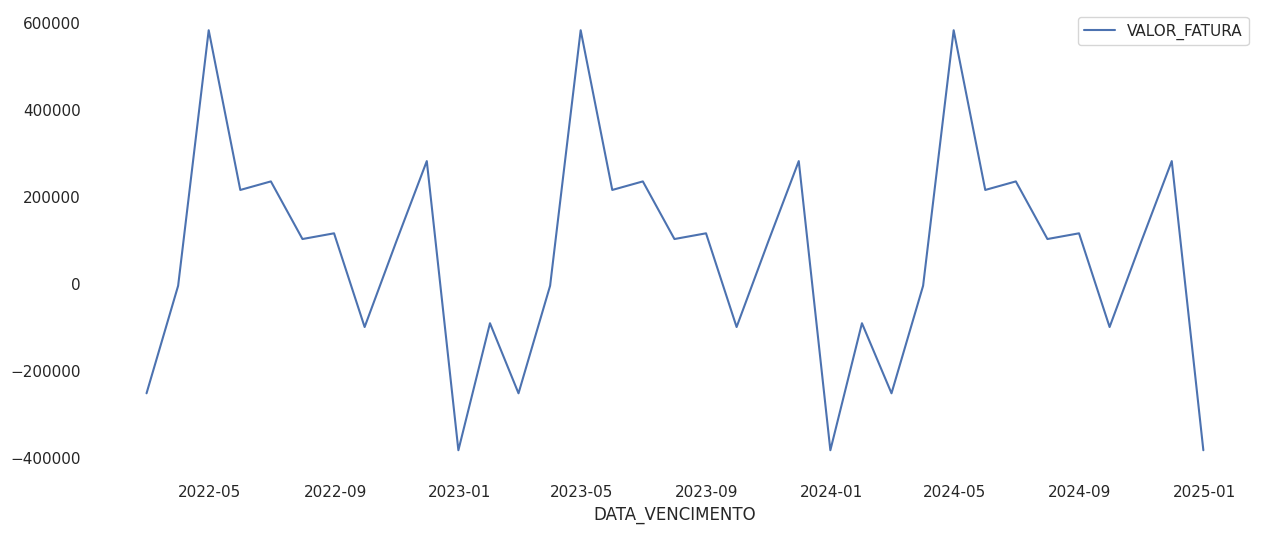

In [45]:
season_index = df.index.month
sazonalidade = diferenca.groupby(season_index).transform('mean')
sns.lineplot(sazonalidade);

### Isolamento do ruído (resíduo): parte aleatória da série após remoção da tendência e da sazonalidade

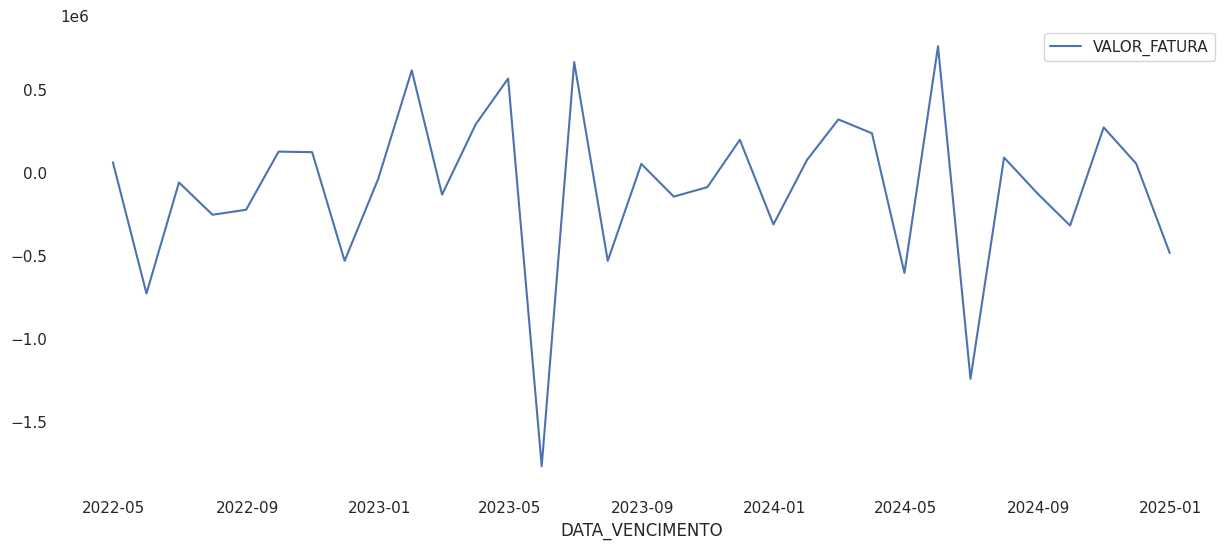

In [46]:
ruido = diferenca_2 - sazonalidade
sns.lineplot(ruido);

### REVERSÃO DA TRANSFORMAÇÃO E DIFERENCIAÇÃO

Ao realizarmos a transformação e diferenciação das séries temporais<br>
alteramos os valores das séries, logo para fazermos previsões<br>
temos que realizar a reversão da trasnformação e diferenciação das séries<br>

Reversão da transformação por logatitimo natural de base e

In [48]:
df_log_revertida =  np.e**df_log
df_log_revertida.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,2266691.11
2022-03-31,2243767.25
2022-04-30,2861797.77


Reversão da transformação por raiz cúbica (quando possui dados com valor zero ou negativos)

In [49]:
df_square_revertida = df_square**3
df_square_revertida.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,2266691.11
2022-03-31,2243767.25
2022-04-30,2861797.77


### REVERSÃO DA DIFERENCIAÇÃO

Lembrando que iremos perder o primeiro valor pois não temos o antecessor para subtrair

In [63]:
diferenca_revertida = df.shift(1) + diferenca
diferenca_revertida.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-28,NaN
2022-03-31,2243767.25
2022-04-30,2861797.77
